In [821]:
import math
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

In [822]:
def get_data(name):    
    data = pd.read_csv(name)
    # if data['point_diff'] == -1, its NaN
    data['point_diff'] = data['point_diff'].replace(-1, np.nan)
    data['timestamp'] = data['timestamp'].replace(0, np.nan)
    data['timestamp'] = pd.to_datetime(data['timestamp'], unit='s')
    return data

In [823]:
# lib functions


#find all players
def find_players(data):
    players = set()
    for i, row in data.iterrows():
        players_team1 = row['team1'].split(' ')
        players_team2 = row['team2'].split(' ')
        for player in players_team1:
            players.add(player)
        for player in players_team2:
            players.add(player)
    players = list(players)     
    return players

def number_of_wins(data, player):
    total_games = 0
    wins = 0
    for i, row in data.iterrows():
        players_team1 = row['team1'].split(' ')
        players_team2 = row['team2'].split(' ')
        if player in players_team1:
            if row['winner'] == 'team1':
                wins += 1
            total_games += 1
        elif player in players_team2:
            if row['winner'] == 'team2':
                wins += 1
            total_games += 1    
    return total_games, wins

from collections import defaultdict

def player_team_stats(data, players):
  team_stats = {player: defaultdict(int) for player in players}
  
  for _, row in data.iterrows():
    team1_players = row['team1'].split(' ')
    team2_players = row['team2'].split(' ')
    
    for player in team1_players:
      for teammate in team1_players:
        if player != teammate:
          team_stats[player][teammate] += 1
    
    for player in team2_players:
      for teammate in team2_players:
        if player != teammate:
          team_stats[player][teammate] += 1
    
  for player in team_stats:
    team_stats[player] = dict(sorted(team_stats[player].items(), key=lambda item: item[1], reverse=True))
  
  return team_stats


from collections import defaultdict
def find_teammate_wins(data):
  # Initialize dictionaries to store wins and losses for each player-teammate pair
  player_teammate_wins = defaultdict(lambda: defaultdict(int))
  player_teammate_losses = defaultdict(lambda: defaultdict(int))

  # Iterate through each row in the dataset
  for _, row in data.iterrows():
      # Split the teams into individual players
      team1_players = row['team1'].split()
      team2_players = row['team2'].split()
      
      # Determine the winning and losing teams
      if row['winner'] == 'team1':
          winning_team = team1_players
          losing_team = team2_players
      elif row['winner'] == 'team2':
          winning_team = team2_players
          losing_team = team1_players
      else:
          continue  # Skip if no winner is determined
      
      # Update the win count for each player-teammate pair in the winning team
      for player in winning_team:
          for teammate in winning_team:
              if player != teammate:  # Exclude self-pairing
                  player_teammate_wins[player][teammate] += 1
      
      # Update the loss count for each player-teammate pair in the losing team
      for player in losing_team:
          for teammate in losing_team:
              if player != teammate:  # Exclude self-pairing
                  player_teammate_losses[player][teammate] += 1

  # Find the teammate with the most wins and losses for each player
  most_wins_with_teammate = {}
  most_losses_with_teammate = {}

  for player, teammates in player_teammate_wins.items():
      most_wins_with_teammate[player] = max(teammates, key=teammates.get)

  for player, teammates in player_teammate_losses.items():
      most_losses_with_teammate[player] = max(teammates, key=teammates.get)
  return most_wins_with_teammate, most_losses_with_teammate

def find_teammate_winrate(data):
    # Initialize dictionaries to store wins and total games for each player-teammate pair
    player_teammate_wins = defaultdict(lambda: defaultdict(int))
    player_teammate_games = defaultdict(lambda: defaultdict(int))

    # Iterate through each row in the dataset
    for _, row in data.iterrows():
        # Split the teams into individual players
        team1_players = row['team1'].split()
        team2_players = row['team2'].split()
        
        # Determine the winning team
        if row['winner'] == 'team1':
            winning_team = team1_players
        elif row['winner'] == 'team2':
            winning_team = team2_players
        else:
            continue  # Skip if no winner is determined
        
        # Update the total games count for all teammates in both teams
        for player in team1_players:
            for teammate in team1_players:
                if player != teammate:  # Exclude self-pairing
                    player_teammate_games[player][teammate] += 1
        for player in team2_players:
            for teammate in team2_players:
                if player != teammate:  # Exclude self-pairing
                    player_teammate_games[player][teammate] += 1
        
        # Update the win count for teammates in the winning team
        for player in winning_team:
            for teammate in winning_team:
                if player != teammate:  # Exclude self-pairing
                    player_teammate_wins[player][teammate] += 1

    # Calculate the win rate for each player-teammate pair
    player_teammate_winrate = defaultdict(dict)
    for player, teammates in player_teammate_games.items():
        for teammate, games in teammates.items():
            wins = player_teammate_wins[player][teammate]
            winrate = (wins / games) * 100 if games > 0 else 0
            player_teammate_winrate[player][teammate] = winrate
    return player_teammate_winrate

def player_teammate_weighted_winrate(data):
    player_teammate_wins = defaultdict(lambda: defaultdict(int))
    player_teammate_games = defaultdict(lambda: defaultdict(int))

    # Iterate through each row in the dataset
    for _, row in data.iterrows():
        # Split the teams into individual players
        team1_players = row['team1'].split()
        team2_players = row['team2'].split()
        
        # Determine the winning team
        if row['winner'] == 'team1':
            winning_team = team1_players
        elif row['winner'] == 'team2':
            winning_team = team2_players
        else:
            continue  # Skip if no winner is determined
        
        # Update the total games count for all teammates in both teams
        for player in team1_players:
            for teammate in team1_players:
                if player != teammate:  # Exclude self-pairing
                    player_teammate_games[player][teammate] += 1
        for player in team2_players:
            for teammate in team2_players:
                if player != teammate:  # Exclude self-pairing
                    player_teammate_games[player][teammate] += 1
        
        # Update the win count for teammates in the winning team
        for player in winning_team:
            for teammate in winning_team:
                if player != teammate:  # Exclude self-pairing
                    player_teammate_wins[player][teammate] += 1

    # Calculate the weighted win rate for each player-teammate pair
    player_teammate_weighted_winrate = defaultdict(dict)
    for player, teammates in player_teammate_games.items():
        for teammate, games in teammates.items():
            wins = player_teammate_wins[player][teammate]
            # Weighted win rate: winrate * (games / max_games)
            max_games = max(teammates.values())  # Normalize by the maximum games played with any teammate
            weighted_winrate = (wins / games) * (games / max_games) * 100 if games > 0 else 0
            player_teammate_weighted_winrate[player][teammate] = weighted_winrate
    return player_teammate_weighted_winrate


def calc_player_teammate_percentage(data):
    # Initialize dictionaries to store total games for each player and games with teammates
    player_total_games = defaultdict(int)
    player_teammate_games = defaultdict(lambda: defaultdict(int))

    # Iterate through each row in the dataset
    for _, row in data.iterrows():
        # Split the teams into individual players
        team1_players = row['team1'].split()
        team2_players = row['team2'].split()
        
        # Update the total games count for all players
        for player in team1_players + team2_players:
            player_total_games[player] += 1
        
        # Update the games count for teammates in both teams
        for player in team1_players:
            for teammate in team1_players:
                if player != teammate:  # Exclude self-pairing
                    player_teammate_games[player][teammate] += 1
        for player in team2_players:
            for teammate in team2_players:
                if player != teammate:  # Exclude self-pairing
                    player_teammate_games[player][teammate] += 1

    # Calculate the percentage of games played with each teammate
    player_teammate_percentage = defaultdict(dict)
    for player, teammates in player_teammate_games.items():
        total_games = player_total_games[player]
        for teammate, games in teammates.items():
            percentage = (games / total_games) * 100 if total_games > 0 else 0
            player_teammate_percentage[player][teammate] = percentage
    return player_teammate_percentage


def cacl_player_opponent_stats(data):
    # Initialize dictionaries to store total games and wins against opponents
    player_opponent_games = defaultdict(lambda: defaultdict(int))
    player_opponent_wins = defaultdict(lambda: defaultdict(int))

    # Iterate through each row in the dataset
    for _, row in data.iterrows():
        # Split the teams into individual players
        team1_players = row['team1'].split()
        team2_players = row['team2'].split()
        
        # Determine the winning team
        if row['winner'] == 'team1':
            winning_team = team1_players
            losing_team = team2_players
        elif row['winner'] == 'team2':
            winning_team = team2_players
            losing_team = team1_players
        else:
            continue  # Skip if no winner is determined
        
        # Update the total games count for opponents
        for player in team1_players:
            for opponent in team2_players:
                player_opponent_games[player][opponent] += 1
        for player in team2_players:
            for opponent in team1_players:
                player_opponent_games[player][opponent] += 1
        
        # Update the win count for players against opponents
        for player in winning_team:
            for opponent in losing_team:
                player_opponent_wins[player][opponent] += 1
    return player_opponent_games, player_opponent_wins

def calc_longest_streak(data):
    # Initialize dictionaries to store streaks for each player
    longest_winning_streak = defaultdict(int)
    longest_losing_streak = defaultdict(int)
    current_winning_streak = defaultdict(int)
    current_losing_streak = defaultdict(int)

    # Sort the data by timestamp to process games in chronological order
    data = data.sort_values(by='timestamp')

    # Iterate through each row in the dataset
    for _, row in data.iterrows():
        # Split the teams into individual players
        team1_players = row['team1'].split()
        team2_players = row['team2'].split()
        
        # Determine the winning and losing teams
        if row['winner'] == 'team1':
            winning_team = team1_players
            losing_team = team2_players
        elif row['winner'] == 'team2':
            winning_team = team2_players
            losing_team = team1_players
        else:
            continue  # Skip if no winner is determined
        
        # Update streaks for the winning team
        for player in winning_team:
            current_winning_streak[player] += 1
            current_losing_streak[player] = 0  # Reset losing streak
            longest_winning_streak[player] = max(longest_winning_streak[player], current_winning_streak[player])
        
        # Update streaks for the losing team
        for player in losing_team:
            current_losing_streak[player] += 1
            current_winning_streak[player] = 0  # Reset winning streak
            longest_losing_streak[player] = max(longest_losing_streak[player], current_losing_streak[player])
    return longest_winning_streak, longest_losing_streak



def calc_streaks(data):
    # Initialize dictionaries to track current streaks for each player
    current_winning_streak = defaultdict(int)
    current_losing_streak = defaultdict(int)

    # Sort the data by timestamp to process games in chronological order
    data = data.sort_values(by='timestamp')

    # Iterate through each row in the dataset
    for _, row in data.iterrows():
        # Split the teams into individual players
        team1_players = row['team1'].split()
        team2_players = row['team2'].split()
        
        # Determine the winning and losing teams
        if row['winner'] == 'team1':
            winning_team = team1_players
            losing_team = team2_players
        elif row['winner'] == 'team2':
            winning_team = team2_players
            losing_team = team1_players
        else:
            continue  # Skip if no winner is determined
        
        # Update streaks for the winning team
        for player in winning_team:
            current_winning_streak[player] += 1
            current_losing_streak[player] = 0  # Reset losing streak
        
        # Update streaks for the losing team
        for player in losing_team:
            current_losing_streak[player] += 1
            current_winning_streak[player] = 0  # Reset winning streak
    return current_winning_streak, current_losing_streak


#for each player find all games and sort them by timestamp
def player_game_history(data, player):
    game_history = []
    for _, row in data.iterrows():
        players_team1 = row['team1'].split()
        players_team2 = row['team2'].split()
        if player in players_team1:
            game_history.append((row['timestamp'], row['winner'] == 'team1'))
        elif player in players_team2:
            game_history.append((row['timestamp'], row['winner'] == 'team2'))
    game_history.sort(key=lambda x: x[0])  # Sort by timestamp
    return game_history

#map winrate over time for player
def player_winrate_over_time(data, player):
    game_history = player_game_history(data, player)
    winrates = []
    for i in range(len(game_history)):
        wins = sum(1 for j in range(i+1) if game_history[j][1])
        winrate = (wins / (i + 1)) * 100
        winrates.append((game_history[i][0], winrate))
    return winrates

def most_active_players(data, n):
    """
    Return the N most active players sorted by the number of games played.

    Args:
        data (DataFrame): The dataset containing game data.
        n (int): The number of top players to return.

    Returns:
        list: A list of tuples containing player names and the number of games played.
    """
    # Dictionary to store the number of games played by each player
    player_game_count = defaultdict(int)

    # Iterate through the dataset and count games for each player
    for _, row in data.iterrows():
        team1_players = row['team1'].split()
        team2_players = row['team2'].split()
        for player in team1_players + team2_players:
            player_game_count[player] += 1

    # Sort players by the number of games played in descending order
    sorted_players = sorted(player_game_count.items(), key=lambda x: x[1], reverse=True)

    # Return the top N players
    return sorted_players[:n]


In [824]:
from itertools import combinations

def divide_teams(players, win_rates):
    """
    Divide players into two fair teams by trying all possible combinations.

    Args:
        players (list): List of player names to divide into teams.
        win_rates (dict): Dictionary of player win rates (e.g., {'Adam': 75, 'Jirka': 60}).

    Returns:
        tuple: Two lists representing Team 1 and Team 2.
    """
    # Generate all possible combinations for one team
    n = len(players) // 2
    possible_teams = list(combinations(players, n))

    # Initialize variables to track the best team split
    best_team1, best_team2 = None, None
    team1_final_strength, team2_final_strength = 0, 0
    smallest_difference = float('inf')


    # Iterate through all possible team combinations
    for team1 in possible_teams:
        team2 = [player for player in players if player not in team1]

        # Calculate the total strength of both teams
        team1_strength = sum(win_rates.get(player, 0) for player in team1)
        team2_strength = sum(win_rates.get(player, 0) for player in team2)

        # Calculate the difference in strength between the two teams
        strength_difference = abs(team1_strength - team2_strength)

    
        # Update the best team split if the current one is more balanced
        if strength_difference < smallest_difference:
            smallest_difference = strength_difference
            best_team1, best_team2 = team1, team2
            team1_final_strength = team1_strength
            team2_final_strength = team2_strength

    return list(best_team1), list(best_team2), team1_final_strength, team2_final_strength

def divide_teams_weighted(players, win_rates, games_played, k=10):
    """
    Divide players into two fair teams by weighting win rates based on games played.

    Args:
        players (list): List of player names to divide into teams.
        win_rates (dict): Dictionary of player win rates (e.g., {'Adam': 75, 'Jirka': 60}).
        games_played (dict): Dictionary of games played by each player (e.g., {'Adam': 50, 'Jirka': 20}).
        k (int): A constant to control the weight of games played in the win rate adjustment.

    Returns:
        tuple: Two lists representing Team 1 and Team 2.
    """
    # Calculate weighted win rates for each player
    weighted_win_rates = {}
    for player in players:
        winrate = win_rates.get(player, 0)
        games = games_played.get(player, 0)
        weighted_win_rates[player] = (winrate * games) / (games + k) if games > 0 else 0

    # Generate all possible combinations for one team
    n = len(players) // 2
    possible_teams = list(combinations(players, n))

    # Initialize variables to track the best team split
    best_team1, best_team2 = None, None
    smallest_difference = float('inf')
    team1_final_strength, team2_final_strength = 0, 0

    # Iterate through all possible team combinations
    for team1 in possible_teams:
        team2 = [player for player in players if player not in team1]

        # Calculate the total strength of both teams
        team1_strength = sum(weighted_win_rates.get(player, 0) for player in team1)
        team2_strength = sum(weighted_win_rates.get(player, 0) for player in team2)

        # Calculate the difference in strength between the two teams
        strength_difference = abs(team1_strength - team2_strength)

        # Update the best team split if the current one is more balanced
        if strength_difference < smallest_difference:
            smallest_difference = strength_difference
            best_team1, best_team2 = team1, team2
            team1_final_strength = team1_strength
            team2_final_strength = team2_strength

    return list(best_team1), list(best_team2), team1_final_strength, team2_final_strength


In [825]:

def plot_games_per_month(data):
# Group data by month and year, and count the number of games
  monthly_games = data.groupby(data['timestamp'].dt.to_period('M')).size()

  # Convert the index to datetime for plotting
  monthly_games.index = monthly_games.index.to_timestamp()

  # Plot the bar graph
  plt.figure(figsize=(10, 6))
  monthly_games.plot(kind='bar', color='skyblue')
  plt.title('Number of Games Played Per Month')
  plt.xlabel('Month')
  plt.ylabel('Number of Games')
  plt.xticks(rotation=45)
  plt.gca().set_xticklabels(monthly_games.index.strftime('%Y-%m'))  # Format x-axis labels to show year and month
  plt.tight_layout()
  plt.show()

  

In [826]:
def plot_point_diff_distirb(data):
  # Plot the distribution of point differences
  plt.figure(figsize=(10, 6))
  plt.hist(data['point_diff'], bins=20, color='skyblue', edgecolor='black')
  plt.title('Point Difference Distribution')
  plt.xlabel('Point Difference')
  plt.ylabel('Frequency')
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.tight_layout()
  plt.show()

In [827]:
def plot_map_occurences(data):
  # Count the occurrences of each map
  map_counts = data['map'].value_counts()

  # Plot the most popular maps
  plt.figure(figsize=(10, 6))
  map_counts.plot(kind='bar', color='skyblue', edgecolor='black')
  plt.title('Most Popular Maps')
  plt.xlabel('Map')
  plt.ylabel('Number of Games')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

In [828]:
def plot_winrate(data, player):
    data = player_winrate_over_time(data, player)
   # Filter out entries where timestamp is NaT or winrate is NaN
    clean_data = [
        (ts.to_pydatetime() if isinstance(ts, pd.Timestamp) else ts, float(wr))
        for ts, wr in data
        if pd.notna(ts) and pd.notna(wr)
    ]

    if not clean_data:
        print("No valid data to plot.")
        return
    
    clean_data.sort(key=lambda x: x[0])

    timestamps, winrates = zip(*clean_data)
    print(timestamps)

    # Create the plot
    plt.figure(figsize=(10, 5))
    plt.plot(timestamps, winrates, linestyle='-', color='blue')

    # Formatting
    plt.title('Winrate Over Time for ' + player)
    plt.xlabel('Time')
    plt.ylabel('Winrate (%)')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [829]:
def plot_all_players_winrates(data, players):
    plt.figure(figsize=(10, 5))
    for player in players:
        winrates = player_winrate_over_time(data, player)
        # Filter out entries where timestamp is NaT or winrate is NaN
        clean_data = [
            (ts.to_pydatetime() if isinstance(ts, pd.Timestamp) else ts, float(wr))
            for ts, wr in winrates
            if pd.notna(ts) and pd.notna(wr)
        ]
        clean_data.sort(key=lambda x: x[0])

        if clean_data:
            timestamps, winrates = zip(*clean_data)
            plt.plot(timestamps, winrates, label=player)
    # Formatting
    plt.title('Winrate Over Time for All Players')
    plt.xlabel('Time')
    plt.ylabel('Winrate (%)')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [830]:
def plot_player_wins_losses(data, player):
    """
    Plot a player's wins and losses over time with wins as 1 and losses as 0.

    Args:
        player (str): The name of the player to plot.
    """
    # Extract the player's game history
    game_history = player_game_history(data, player)

    # Clean the data to ensure valid timestamps and results
    clean_data = [
        (ts.to_pydatetime() if isinstance(ts, pd.Timestamp) else ts, int(wr))
        for ts, wr in game_history
        if pd.notna(ts) and pd.notna(wr)
    ]

    # Sort the data by timestamp
    clean_data.sort(key=lambda x: x[0])

    # Extract timestamps and results for plotting
    timestamps, results = zip(*clean_data)

    # Plot wins and losses
    plt.figure(figsize=(10, 6))
    plt.scatter(timestamps, results, c=["green" if r == 1 else "red" for r in results], label="Game Outcome", alpha=0.7)
    # plt.plot(timestamps, results, label="Game Outcome", color="blue", marker="o", linestyle="-")

    plt.title(f"{player}'s Wins and Losses Over Time")
    plt.xlabel("Time")
    plt.ylabel("Game Outcome (1 = Win, 0 = Loss)")
    plt.yticks([0, 1], labels=["Loss", "Win"])
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

In [831]:
data = get_data('scores.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   team1       108 non-null    object        
 1   team2       108 non-null    object        
 2   winner      108 non-null    object        
 3   map         37 non-null     object        
 4   mode        108 non-null    object        
 5   point_diff  33 non-null     float64       
 6   timestamp   107 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 6.0+ KB


In [832]:
data

,team1,team2,winner,map,mode,point_diff,timestamp
0,Adam Jirka,Lukas Ondra,team2,Death Toll,normal,NaN,2025-01-23 21:34:00
1,Adam Jirka,Lukas Vitek,team1,Blood Harvest,normal,NaN,2025-01-03 21:24:00
2,Adam Jirka,Lukas Vitek,team2,NaN,normal,NaN,2025-01-03 20:05:00
3,Adam Jirka,Ondra Simon,team1,NaN,normal,NaN,2025-01-18 00:23:00
4,Adam Jirka Lukas,Ondra Tomas Vitek,team2,NaN,normal,NaN,2024-01-22 20:25:00
...,...,...,...,...,...,...,...
103,Adam Jirka Vitek,Lukas Simon Tomas,team2,Dead Air,realism,85.0,2025-03-31 20:39:43
104,Adam Ondra Tomas,Jirka Lukas,team1,Dead Center,realism,120.0,2025-04-04 20:02:51
105,Lukas Ondra Tomas,Adam Jirka,team1,Dark Carnival,realism,953.0,2025-04-04 21:26:05
106,Lukas Ondra Simon,Adam Jirka Ondra,team1,Swamp Fever,realism,502.0,2025-04-06 20:00:05


In [833]:
players = find_players(data)
print(players)

['Vitek', 'Mikulas', 'Marek', 'Adam', 'Marco', 'Tomas', 'Rohlicek', 'Jirka', 'Simon', 'Ondra', 'Filip', "O'Neil", 'Lukas']


In [834]:
top_players = most_active_players(data, 7)
active_players = []
for player, games in top_players:
    print(f"{player}: {games} games")
    active_players.append(player)

Jirka: 106 games
Lukas: 89 games
Vitek: 87 games
Ondra: 83 games
Adam: 73 games
Tomas: 67 games
Simon: 50 games


In [835]:
player_win_rates = {}

for player in players:
    games, wins = number_of_wins(data, player)
    winrate = wins / games
    player_win_rates[player] = winrate  

In [836]:
for player in players:
    games, wins = number_of_wins(data, player)
    winrate = wins / games
    print(f'{player}: {games} games, {wins} wins, {winrate:.2%}')

Vitek: 87 games, 40 wins, 45.98%
Mikulas: 11 games, 5 wins, 45.45%
Marek: 8 games, 2 wins, 25.00%
Adam: 73 games, 12 wins, 16.44%
Marco: 6 games, 3 wins, 50.00%
Tomas: 67 games, 37 wins, 55.22%
Rohlicek: 1 games, 0 wins, 0.00%
Jirka: 106 games, 76 wins, 71.70%
Simon: 50 games, 27 wins, 54.00%
Ondra: 82 games, 47 wins, 57.32%
Filip: 2 games, 0 wins, 0.00%
O'Neil: 11 games, 7 wins, 63.64%
Lukas: 89 games, 41 wins, 46.07%


In [841]:
weighted_win_rates = {}
games_played = {}
k = 10
for player, games in most_active_players(data, len(players)):
  games_played[player] = games
  
for player in players:
    winrate = player_win_rates.get(player, 0)
    games = games_played.get(player, 0)
    weighted_win_rates[player] = (winrate * games) / (games + k) if games > 0 else 0
    print(f'{player}: {games} games, {winrate:.2%} winrate, {weighted_win_rates[player]:.2%} weighted winrate')


Vitek: 87 games, 45.98% winrate, 41.24% weighted winrate
Mikulas: 11 games, 45.45% winrate, 23.81% weighted winrate
Marek: 8 games, 25.00% winrate, 11.11% weighted winrate
Adam: 73 games, 16.44% winrate, 14.46% weighted winrate
Marco: 6 games, 50.00% winrate, 18.75% weighted winrate
Tomas: 67 games, 55.22% winrate, 48.05% weighted winrate
Rohlicek: 1 games, 0.00% winrate, 0.00% weighted winrate
Jirka: 106 games, 71.70% winrate, 65.52% weighted winrate
Simon: 50 games, 54.00% winrate, 45.00% weighted winrate
Ondra: 83 games, 57.32% winrate, 51.15% weighted winrate
Filip: 2 games, 0.00% winrate, 0.00% weighted winrate
O'Neil: 11 games, 63.64% winrate, 33.33% weighted winrate
Lukas: 89 games, 46.07% winrate, 41.41% weighted winrate


In [ ]:


team_stats = player_team_stats(data, players)
  
for player, teammates in team_stats.items():
  print(f"{player}:")
  for teammate, count in teammates.items():
    print(f"  {teammate}: {count} games")

Vitek:
  Jirka: 32 games
  Lukas: 26 games
  Ondra: 25 games
  Adam: 23 games
  Tomas: 19 games
  Simon: 18 games
  O'Neil: 8 games
  Mikulas: 5 games
  Marco: 4 games
  Marek: 2 games
  Filip: 1 games
Mikulas:
  Jirka: 7 games
  Vitek: 5 games
  Lukas: 4 games
  Ondra: 3 games
  Adam: 2 games
  Simon: 2 games
  Tomas: 2 games
  Marco: 1 games
  O'Neil: 1 games
Marek:
  Adam: 4 games
  Jirka: 3 games
  Lukas: 3 games
  Vitek: 2 games
  Tomas: 2 games
  Simon: 2 games
Adam:
  Jirka: 27 games
  Lukas: 27 games
  Vitek: 23 games
  Ondra: 18 games
  Tomas: 17 games
  Simon: 13 games
  Marek: 4 games
  Mikulas: 2 games
  O'Neil: 2 games
  Marco: 1 games
  Rohlicek: 1 games
Marco:
  Jirka: 5 games
  Vitek: 4 games
  Ondra: 2 games
  Tomas: 2 games
  Adam: 1 games
  Lukas: 1 games
  Mikulas: 1 games
Tomas:
  Ondra: 28 games
  Jirka: 27 games
  Lukas: 20 games
  Vitek: 19 games
  Adam: 17 games
  Simon: 13 games
  O'Neil: 3 games
  Marco: 2 games
  Mikulas: 2 games
  Marek: 2 games
Rohlicek:
 

In [ ]:

most_losses_with_teammate, most_wins_with_teammate = find_teammate_wins(data)
# Display the results
print("Teammates with the most wins:")
for player, teammate in most_wins_with_teammate.items():
    print(f"{player} has the most wins with {teammate}.")

print("\nTeammates with the most losses:")
for player, teammate in most_losses_with_teammate.items():
    print(f"{player} has the most losses with {teammate}.")

Teammates with the most wins:
Adam has the most wins with Lukas.
Jirka has the most wins with Adam.
Lukas has the most wins with Adam.
Vitek has the most wins with Adam.
Ondra has the most wins with Adam.
Simon has the most wins with Lukas.
Marco has the most wins with Jirka.
Tomas has the most wins with Adam.
Marek has the most wins with Adam.
O'Neil has the most wins with Vitek.
Rohlicek has the most wins with Adam.
Mikulas has the most wins with Tomas.
Filip has the most wins with Simon.

Teammates with the most losses:
Lukas has the most losses with Jirka.
Ondra has the most losses with Jirka.
Adam has the most losses with Jirka.
Jirka has the most losses with Ondra.
Vitek has the most losses with Jirka.
Tomas has the most losses with Jirka.
Simon has the most losses with Jirka.
Mikulas has the most losses with Jirka.
O'Neil has the most losses with Vitek.
Marco has the most losses with Jirka.
Marek has the most losses with Jirka.


In [ ]:

# Display the win rates
player_teammate_winrate = find_teammate_winrate(data)
print("Win rates for each player with their teammates:")
for player, teammates in player_teammate_winrate.items():
    print(f"\n{player}:")
    sorted_teammates = sorted(teammates.items(), key=lambda x: x[1], reverse=True)
    for teammate, winrate in sorted_teammates:
        print(f"  With {teammate}: {winrate:.2f}% win rate")

Win rates for each player with their teammates:

Adam:
  With Mikulas: 50.00% win rate
  With O'Neil: 50.00% win rate
  With Jirka: 33.33% win rate
  With Simon: 15.38% win rate
  With Tomas: 11.76% win rate
  With Ondra: 11.11% win rate
  With Vitek: 8.70% win rate
  With Lukas: 7.41% win rate
  With Marco: 0.00% win rate
  With Marek: 0.00% win rate
  With Rohlicek: 0.00% win rate

Jirka:
  With O'Neil: 100.00% win rate
  With Simon: 87.50% win rate
  With Tomas: 85.19% win rate
  With Ondra: 82.86% win rate
  With Lukas: 76.92% win rate
  With Vitek: 75.00% win rate
  With Mikulas: 71.43% win rate
  With Marco: 60.00% win rate
  With Adam: 33.33% win rate
  With Marek: 33.33% win rate

Lukas:
  With Jirka: 76.92% win rate
  With O'Neil: 60.00% win rate
  With Tomas: 55.00% win rate
  With Ondra: 53.33% win rate
  With Mikulas: 50.00% win rate
  With Simon: 50.00% win rate
  With Vitek: 42.31% win rate
  With Marek: 33.33% win rate
  With Adam: 7.41% win rate
  With Marco: 0.00% win 

In [ ]:

# Display the weighted win rates
print("Weighted win rates for each player with their teammates (sorted):")
for player, teammates in player_teammate_weighted_winrate(data).items():
    print(f"\n{player}:")
    # Sort teammates by weighted win rate in descending order
    sorted_teammates = sorted(teammates.items(), key=lambda x: x[1], reverse=True)
    for teammate, weighted_winrate in sorted_teammates:
        print(f"  With {teammate}: {weighted_winrate:.2f}% weighted win rate")

Weighted win rates for each player with their teammates (sorted):

Adam:
  With Jirka: 33.33% weighted win rate
  With Lukas: 7.41% weighted win rate
  With Ondra: 7.41% weighted win rate
  With Tomas: 7.41% weighted win rate
  With Vitek: 7.41% weighted win rate
  With Simon: 7.41% weighted win rate
  With Mikulas: 3.70% weighted win rate
  With O'Neil: 3.70% weighted win rate
  With Marco: 0.00% weighted win rate
  With Marek: 0.00% weighted win rate
  With Rohlicek: 0.00% weighted win rate

Jirka:
  With Ondra: 82.86% weighted win rate
  With Vitek: 68.57% weighted win rate
  With Tomas: 65.71% weighted win rate
  With Lukas: 57.14% weighted win rate
  With Simon: 40.00% weighted win rate
  With Adam: 25.71% weighted win rate
  With Mikulas: 14.29% weighted win rate
  With O'Neil: 8.57% weighted win rate
  With Marco: 8.57% weighted win rate
  With Marek: 2.86% weighted win rate

Lukas:
  With Jirka: 66.67% weighted win rate
  With Ondra: 53.33% weighted win rate
  With Simon: 40.00

In [ ]:

# Display the results
player_teammate_games = player_team_stats(data, players)
player_teammate_percentage = calc_player_teammate_percentage(data)
print("Number of games with each teammate and their percentage of total games:")
for player, teammates in player_teammate_games.items():
    print(f"\n{player}:")
    # Sort teammates by the number of games played together in descending order
    sorted_teammates = sorted(teammates.items(), key=lambda x: x[1], reverse=True)
    for teammate, games in sorted_teammates:
        percentage = player_teammate_percentage[player][teammate]
        print(f"  With {teammate}: {games} games ({percentage:.2f}% of total games)")

Number of games with each teammate and their percentage of total games:

Vitek:
  With Jirka: 32 games (36.78% of total games)
  With Lukas: 26 games (29.89% of total games)
  With Ondra: 25 games (28.74% of total games)
  With Adam: 23 games (26.44% of total games)
  With Tomas: 19 games (21.84% of total games)
  With Simon: 18 games (20.69% of total games)
  With O'Neil: 8 games (9.20% of total games)
  With Mikulas: 5 games (5.75% of total games)
  With Marco: 4 games (4.60% of total games)
  With Marek: 2 games (2.30% of total games)
  With Filip: 1 games (1.15% of total games)

Mikulas:
  With Jirka: 7 games (63.64% of total games)
  With Vitek: 5 games (45.45% of total games)
  With Lukas: 4 games (36.36% of total games)
  With Ondra: 3 games (27.27% of total games)
  With Adam: 2 games (18.18% of total games)
  With Simon: 2 games (18.18% of total games)
  With Tomas: 2 games (18.18% of total games)
  With Marco: 1 games (9.09% of total games)
  With O'Neil: 1 games (9.09% of to

In [ ]:


player_opponent_games, player_opponent_wins = cacl_player_opponent_stats(data)
# Display the most frequent opponents and who has won more games
print("Most frequent opponents and win counts:")
for player, opponents in player_opponent_games.items():
    print(f"\n{player}:")
    # Sort opponents by the number of games played together in descending order
    sorted_opponents = sorted(opponents.items(), key=lambda x: x[1], reverse=True)
    for opponent, games in sorted_opponents:
        wins = player_opponent_wins[player][opponent]
        losses = games - wins
        result = "More Wins" if wins > losses else "More Losses" if losses > wins else "Equal Wins and Losses"
        print(f"  Against {opponent}: {games} games, {wins} wins, {losses} losses ({result})")

Most frequent opponents and win counts:

Adam:
  Against Jirka: 45 games, 3 wins, 42 losses (More Losses)
  Against Ondra: 41 games, 8 wins, 33 losses (More Losses)
  Against Lukas: 33 games, 9 wins, 24 losses (More Losses)
  Against Vitek: 31 games, 5 wins, 26 losses (More Losses)
  Against Tomas: 27 games, 2 wins, 25 losses (More Losses)
  Against Simon: 17 games, 4 wins, 13 losses (More Losses)
  Against O'Neil: 4 games, 0 wins, 4 losses (More Losses)
  Against Marco: 3 games, 0 wins, 3 losses (More Losses)
  Against Mikulas: 2 games, 0 wins, 2 losses (More Losses)
  Against Marek: 1 games, 0 wins, 1 losses (More Losses)

Jirka:
  Against Lukas: 61 games, 41 wins, 20 losses (More Wins)
  Against Vitek: 53 games, 39 wins, 14 losses (More Wins)
  Against Ondra: 46 games, 28 wins, 18 losses (More Wins)
  Against Adam: 45 games, 42 wins, 3 losses (More Wins)
  Against Tomas: 38 games, 25 wins, 13 losses (More Wins)
  Against Simon: 34 games, 21 wins, 13 losses (More Wins)
  Against O'Ne

In [ ]:

longest_winning_streak, longest_losing_streak = calc_longest_streak(data)
# Display the results
print("Longest Winning and Losing Streaks for Each Player:")
for player in set(longest_winning_streak.keys()).union(longest_losing_streak.keys()):
    print(f"{player}:")
    print(f"  Longest Winning Streak: {longest_winning_streak[player]}")
    print(f"  Longest Losing Streak: {longest_losing_streak[player]}")

Longest Winning and Losing Streaks for Each Player:
Vitek:
  Longest Winning Streak: 3
  Longest Losing Streak: 4
Mikulas:
  Longest Winning Streak: 2
  Longest Losing Streak: 4
Marek:
  Longest Winning Streak: 2
  Longest Losing Streak: 6
Adam:
  Longest Winning Streak: 1
  Longest Losing Streak: 13
Marco:
  Longest Winning Streak: 1
  Longest Losing Streak: 1
Tomas:
  Longest Winning Streak: 5
  Longest Losing Streak: 3
Rohlicek:
  Longest Winning Streak: 0
  Longest Losing Streak: 1
Jirka:
  Longest Winning Streak: 9
  Longest Losing Streak: 4
Simon:
  Longest Winning Streak: 6
  Longest Losing Streak: 6
Ondra:
  Longest Winning Streak: 6
  Longest Losing Streak: 4
Filip:
  Longest Winning Streak: 0
  Longest Losing Streak: 2
O'Neil:
  Longest Winning Streak: 4
  Longest Losing Streak: 2
Lukas:
  Longest Winning Streak: 4
  Longest Losing Streak: 3


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# Prepare the dataset
def prepare_dataset(data):
    features = []
    labels = []

    for _, row in data.iterrows():
        team1_players = row['team1'].split()
        team2_players = row['team2'].split()

        # Calculate team statistics
        team1_winrate = np.mean([player_win_rates.get(player, 0) for player in team1_players])
        team2_winrate = np.mean([player_win_rates.get(player, 0) for player in team2_players])

        # Feature: Difference in average win rate
        features.append([team1_winrate - team2_winrate])

        # Label: 1 if team1 wins, 0 if team2 wins
        labels.append(1 if row['winner'] == 'team1' else 0)

    return np.array(features), np.array(labels)

# Prepare features and labels
features, labels = prepare_dataset(data)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

# Train a Random Forest Classifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Function to divide teams using the trained model
def divide_teams_with_model(players, model, player_win_rates):
    # Generate all possible team combinations
    from itertools import combinations
    n = len(players) // 2
    possible_teams = list(combinations(players, n))

    best_team1, best_team2 = None, None
    best_balance = float('inf')

    for team1 in possible_teams:
        team2 = [player for player in players if player not in team1]

        # Calculate team statistics
        team1_winrate = np.mean([player_win_rates.get(player, 0) for player in team1])
        team2_winrate = np.mean([player_win_rates.get(player, 0) for player in team2])

        # Predict the balance using the model
        balance = abs(team1_winrate - team2_winrate)
        if balance < best_balance:
            best_balance = balance
            best_team1, best_team2 = team1, team2

    return best_team1, best_team2

# Example usage
players_to_divide = ['Adam', 'Jirka', 'Simon', 'Lukas', 'Vitek']
team1, team2 = divide_teams_with_model(players_to_divide, model, player_win_rates)

print("Team 1:", team1)
print("Team 2:", team2)

Accuracy: 0.7727272727272727
Team 1: ('Lukas', 'Vitek')
Team 2: ['Adam', 'Jirka', 'Simon']


In [ ]:


# List of players to divide into teams
players_to_divide = ['Adam', 'Jirka', 'Simon', 'Lukas', 'Vitek']

# Divide players into two fair teams
team1, team2, team1_stren, team2_stren = divide_teams(players_to_divide, player_win_rates)

# Display the teams
print("Team 1:", team1)
print("Team 2:", team2)
print("Team 1 Strength:", team1_stren)
print("Team 2 Strength:", team2_stren)
print("diff", abs(team1_stren - team2_stren))

Team 1: ['Jirka', 'Vitek']
Team 2: ['Adam', 'Simon', 'Lukas']
Team 1 Strength: 1.1767512470180004
Team 2 Strength: 1.1650577189472064
diff 0.011693528070793935


In [ ]:
# List of players to divide into teams
players_to_divide = ['Adam', 'Jirka', 'Simon', 'Lukas', 'Vitek']

# Divide players into two fair teams

team1, team2, team1_stren, team2_stren = divide_teams_weighted(players_to_divide, player_win_rates, games_played)

# Display the teams
print("Team 1:", team1)
print("Team 2:", team2)
print("Team 1 Strength:", team1_stren)
print("Team 2 Strength:", team2_stren)
print("diff", abs(team1_stren - team2_stren))

Team 1: ['Jirka', 'Vitek']
Team 2: ['Adam', 'Simon', 'Lukas']
Team 1 Strength: 1.067543547813722
Team 2 Strength: 1.0087197273944262
diff 0.0588238204192959


In [ ]:


# Display the current streaks for each player
current_winning_streak, current_losing_streak = calc_streaks(data)
print("Current Streaks for Each Player:")
for player in set(current_winning_streak.keys()).union(current_losing_streak.keys()):
    if current_winning_streak[player] > 0:
        print(f"{player}: Winning streak of {current_winning_streak[player]} games")
    elif current_losing_streak[player] > 0:
        print(f"{player}: Losing streak of {current_losing_streak[player]} games")
    else:
        print(f"{player}: No active streak")

Current Streaks for Each Player:
Vitek: Winning streak of 1 games
Mikulas: Winning streak of 1 games
Marek: Winning streak of 2 games
Adam: Losing streak of 1 games
Marco: Losing streak of 1 games
Tomas: Winning streak of 4 games
Rohlicek: Losing streak of 1 games
Jirka: Winning streak of 2 games
Simon: Winning streak of 4 games
Ondra: Losing streak of 2 games
Filip: Losing streak of 2 games
O'Neil: Losing streak of 1 games
Lukas: Losing streak of 2 games


['Jirka', 'Lukas', 'Vitek', 'Ondra', 'Adam', 'Tomas', 'Simon']
(datetime.datetime(2023, 8, 4, 15, 33), datetime.datetime(2023, 8, 4, 16, 33), datetime.datetime(2023, 8, 4, 17, 33), datetime.datetime(2023, 8, 5, 18, 37), datetime.datetime(2023, 8, 5, 19, 59), datetime.datetime(2023, 8, 5, 20, 16), datetime.datetime(2023, 8, 7, 19, 6), datetime.datetime(2023, 8, 7, 20, 6), datetime.datetime(2023, 8, 8, 11, 29), datetime.datetime(2023, 8, 8, 20, 31), datetime.datetime(2023, 8, 21, 18, 57), datetime.datetime(2023, 9, 8, 18, 15), datetime.datetime(2023, 11, 4, 17, 33), datetime.datetime(2023, 11, 4, 18, 31), datetime.datetime(2023, 11, 4, 18, 33), datetime.datetime(2023, 11, 24, 20, 54), datetime.datetime(2023, 12, 9, 17, 38), datetime.datetime(2023, 12, 9, 20, 1), datetime.datetime(2023, 12, 25, 0, 5), datetime.datetime(2023, 12, 25, 1, 11), datetime.datetime(2023, 12, 27, 21, 34), datetime.datetime(2023, 12, 30, 19, 24), datetime.datetime(2023, 12, 30, 20, 24), datetime.datetime(2023, 12,

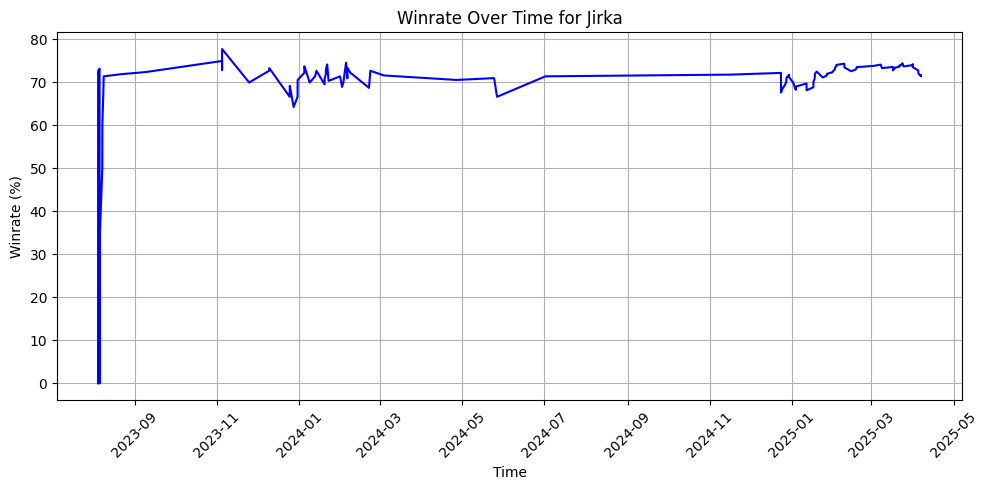

(datetime.datetime(2023, 8, 4, 15, 33), datetime.datetime(2023, 8, 5, 19, 59), datetime.datetime(2023, 8, 7, 19, 6), datetime.datetime(2023, 8, 7, 20, 6), datetime.datetime(2023, 8, 8, 11, 29), datetime.datetime(2023, 8, 8, 20, 31), datetime.datetime(2023, 8, 21, 18, 57), datetime.datetime(2023, 9, 8, 18, 15), datetime.datetime(2023, 11, 4, 17, 33), datetime.datetime(2023, 11, 4, 18, 33), datetime.datetime(2023, 12, 9, 17, 38), datetime.datetime(2023, 12, 9, 20, 1), datetime.datetime(2023, 12, 25, 0, 5), datetime.datetime(2023, 12, 25, 1, 11), datetime.datetime(2023, 12, 27, 21, 34), datetime.datetime(2023, 12, 30, 19, 24), datetime.datetime(2023, 12, 30, 20, 24), datetime.datetime(2023, 12, 30, 21, 33), datetime.datetime(2024, 1, 4, 19, 23), datetime.datetime(2024, 1, 4, 20, 23), datetime.datetime(2024, 1, 4, 21, 23), datetime.datetime(2024, 1, 8, 19, 56), datetime.datetime(2024, 1, 12, 20, 11), datetime.datetime(2024, 1, 13, 20, 16), datetime.datetime(2024, 1, 19, 21, 9), datetime.da

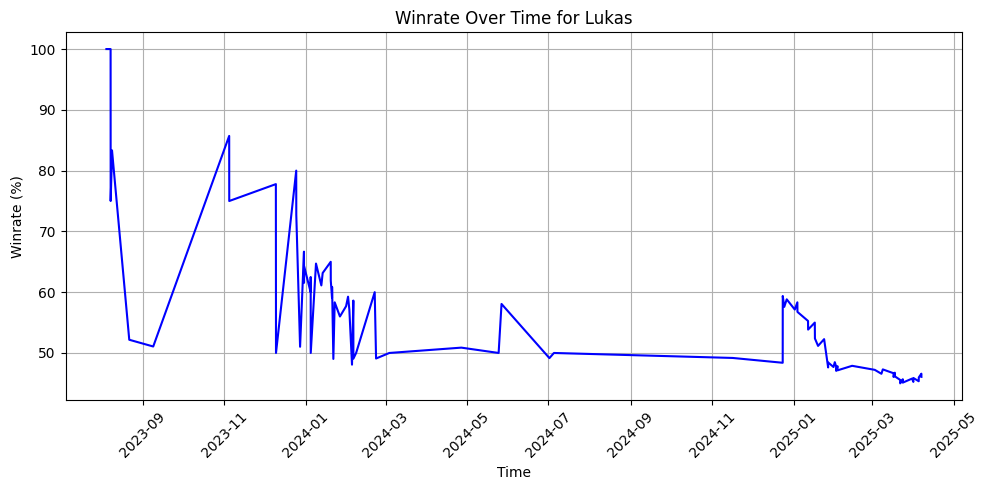

(datetime.datetime(2023, 8, 4, 15, 33), datetime.datetime(2023, 8, 4, 16, 33), datetime.datetime(2023, 8, 4, 17, 33), datetime.datetime(2023, 8, 5, 18, 37), datetime.datetime(2023, 8, 5, 19, 59), datetime.datetime(2023, 8, 5, 20, 16), datetime.datetime(2023, 8, 7, 19, 6), datetime.datetime(2023, 8, 7, 20, 6), datetime.datetime(2023, 8, 8, 11, 29), datetime.datetime(2023, 8, 8, 20, 31), datetime.datetime(2023, 8, 21, 18, 57), datetime.datetime(2023, 9, 8, 18, 15), datetime.datetime(2023, 11, 4, 17, 33), datetime.datetime(2023, 11, 4, 18, 31), datetime.datetime(2023, 11, 4, 18, 33), datetime.datetime(2023, 11, 24, 20, 54), datetime.datetime(2023, 12, 9, 17, 38), datetime.datetime(2023, 12, 9, 20, 1), datetime.datetime(2023, 12, 25, 0, 5), datetime.datetime(2023, 12, 25, 1, 11), datetime.datetime(2023, 12, 30, 19, 24), datetime.datetime(2023, 12, 30, 21, 33), datetime.datetime(2024, 1, 4, 19, 23), datetime.datetime(2024, 1, 4, 20, 23), datetime.datetime(2024, 1, 4, 21, 23), datetime.datet

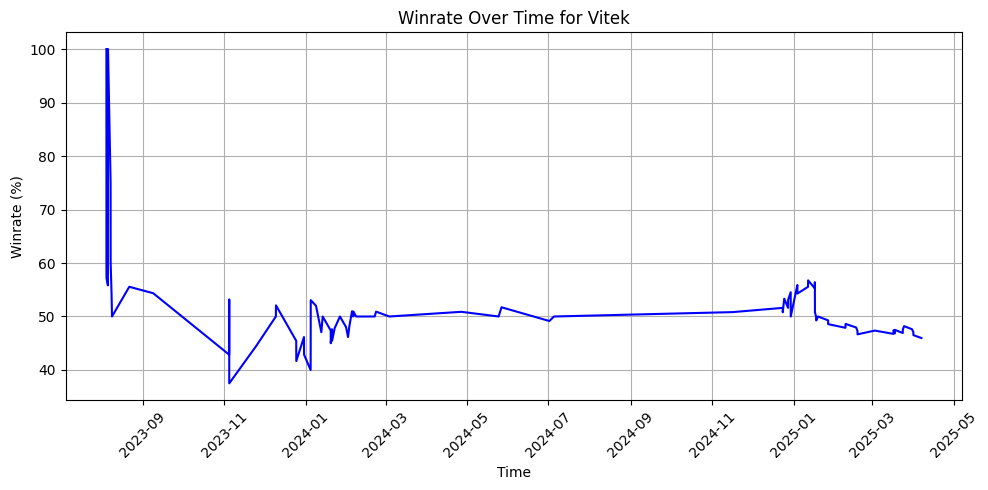

(datetime.datetime(2023, 8, 4, 16, 33), datetime.datetime(2023, 8, 4, 17, 33), datetime.datetime(2023, 8, 5, 18, 37), datetime.datetime(2023, 8, 5, 20, 16), datetime.datetime(2023, 8, 7, 20, 6), datetime.datetime(2023, 8, 8, 11, 29), datetime.datetime(2023, 8, 8, 20, 31), datetime.datetime(2023, 9, 8, 18, 15), datetime.datetime(2023, 11, 4, 17, 33), datetime.datetime(2023, 11, 4, 18, 33), datetime.datetime(2023, 12, 9, 17, 38), datetime.datetime(2023, 12, 9, 20, 1), datetime.datetime(2023, 12, 25, 0, 5), datetime.datetime(2023, 12, 25, 1, 11), datetime.datetime(2023, 12, 27, 21, 34), datetime.datetime(2023, 12, 30, 19, 24), datetime.datetime(2023, 12, 30, 20, 24), datetime.datetime(2023, 12, 30, 21, 33), datetime.datetime(2024, 1, 4, 19, 23), datetime.datetime(2024, 1, 4, 20, 23), datetime.datetime(2024, 1, 4, 21, 23), datetime.datetime(2024, 1, 8, 19, 56), datetime.datetime(2024, 1, 12, 20, 11), datetime.datetime(2024, 1, 13, 20, 16), datetime.datetime(2024, 1, 19, 21, 9), datetime.da

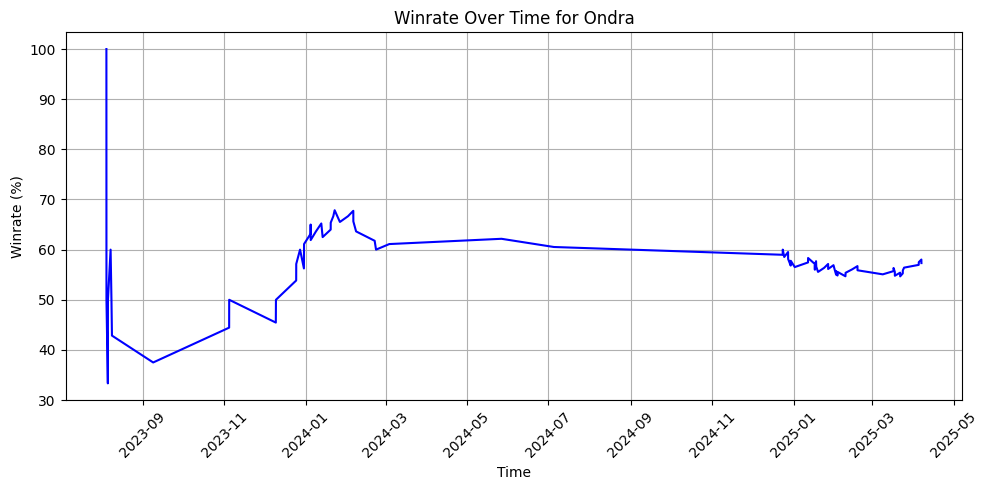

(datetime.datetime(2023, 8, 4, 15, 33), datetime.datetime(2023, 8, 5, 19, 59), datetime.datetime(2023, 8, 5, 20, 16), datetime.datetime(2023, 8, 7, 19, 6), datetime.datetime(2023, 8, 7, 20, 6), datetime.datetime(2023, 8, 8, 20, 31), datetime.datetime(2023, 11, 4, 17, 33), datetime.datetime(2023, 11, 4, 18, 33), datetime.datetime(2023, 11, 24, 20, 54), datetime.datetime(2023, 12, 9, 17, 38), datetime.datetime(2023, 12, 25, 0, 5), datetime.datetime(2023, 12, 25, 1, 11), datetime.datetime(2023, 12, 30, 19, 24), datetime.datetime(2023, 12, 30, 20, 24), datetime.datetime(2024, 1, 4, 19, 23), datetime.datetime(2024, 1, 4, 20, 23), datetime.datetime(2024, 1, 12, 20, 11), datetime.datetime(2024, 1, 13, 20, 16), datetime.datetime(2024, 1, 19, 21, 9), datetime.datetime(2024, 1, 19, 21, 59), datetime.datetime(2024, 1, 22, 20, 25), datetime.datetime(2024, 1, 26, 19, 0), datetime.datetime(2024, 2, 1, 20, 43), datetime.datetime(2024, 2, 2, 20, 7), datetime.datetime(2024, 2, 21, 20, 34), datetime.dat

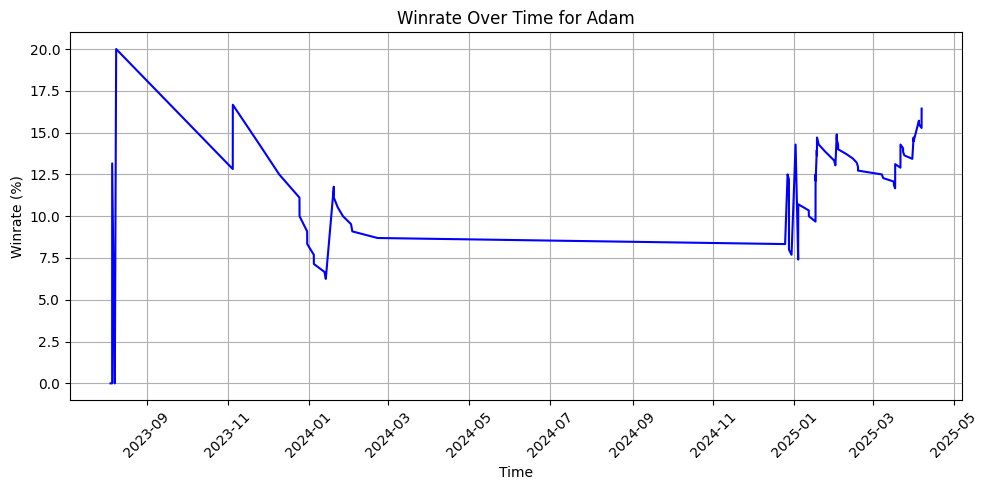

(datetime.datetime(2023, 8, 4, 15, 33), datetime.datetime(2023, 8, 4, 16, 33), datetime.datetime(2023, 8, 4, 17, 33), datetime.datetime(2023, 8, 5, 18, 37), datetime.datetime(2023, 8, 5, 19, 59), datetime.datetime(2023, 8, 5, 20, 16), datetime.datetime(2023, 8, 7, 19, 6), datetime.datetime(2023, 8, 7, 20, 6), datetime.datetime(2023, 8, 8, 11, 29), datetime.datetime(2023, 8, 8, 20, 31), datetime.datetime(2023, 9, 8, 18, 15), datetime.datetime(2023, 11, 4, 17, 33), datetime.datetime(2023, 11, 4, 18, 31), datetime.datetime(2023, 11, 4, 18, 33), datetime.datetime(2023, 11, 24, 20, 54), datetime.datetime(2023, 12, 9, 17, 38), datetime.datetime(2023, 12, 9, 20, 1), datetime.datetime(2023, 12, 25, 0, 5), datetime.datetime(2023, 12, 25, 1, 11), datetime.datetime(2023, 12, 27, 21, 34), datetime.datetime(2023, 12, 30, 19, 24), datetime.datetime(2023, 12, 30, 20, 24), datetime.datetime(2023, 12, 30, 21, 33), datetime.datetime(2024, 1, 4, 19, 23), datetime.datetime(2024, 1, 4, 20, 23), datetime.da

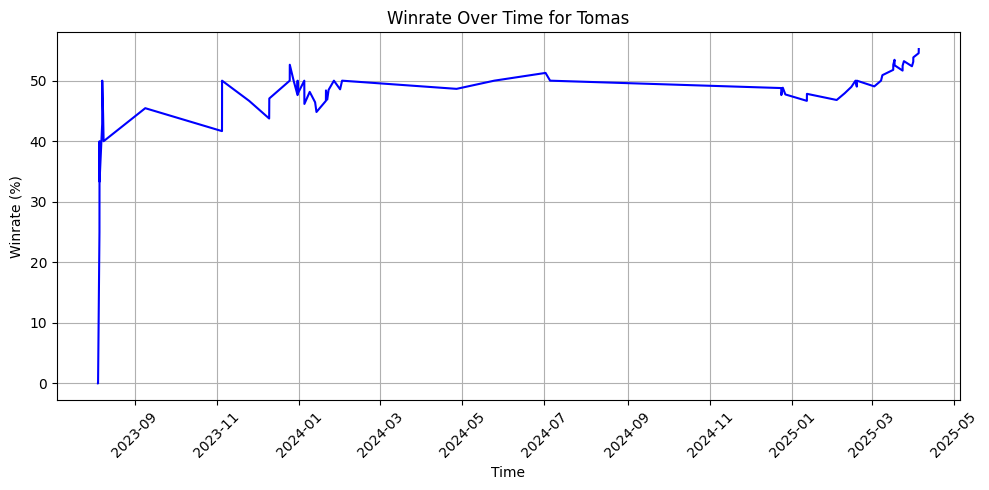

(datetime.datetime(2023, 8, 4, 15, 33), datetime.datetime(2023, 8, 4, 16, 33), datetime.datetime(2023, 8, 4, 17, 33), datetime.datetime(2023, 8, 5, 18, 37), datetime.datetime(2023, 8, 5, 20, 16), datetime.datetime(2023, 8, 7, 20, 6), datetime.datetime(2023, 8, 8, 11, 29), datetime.datetime(2023, 8, 21, 18, 57), datetime.datetime(2023, 11, 4, 18, 31), datetime.datetime(2023, 12, 27, 21, 34), datetime.datetime(2024, 1, 4, 19, 23), datetime.datetime(2024, 1, 4, 20, 23), datetime.datetime(2024, 1, 8, 19, 56), datetime.datetime(2024, 1, 20, 20, 19), datetime.datetime(2024, 1, 20, 21, 35), datetime.datetime(2024, 2, 4, 20, 4), datetime.datetime(2024, 2, 7, 22, 12), datetime.datetime(2024, 2, 21, 20, 34), datetime.datetime(2024, 4, 26, 19, 52), datetime.datetime(2024, 5, 26, 23, 14), datetime.datetime(2024, 11, 16, 7, 59), datetime.datetime(2024, 12, 23, 20, 6), datetime.datetime(2024, 12, 23, 21, 6), datetime.datetime(2024, 12, 24, 23, 46), datetime.datetime(2024, 12, 29, 20, 6), datetime.da

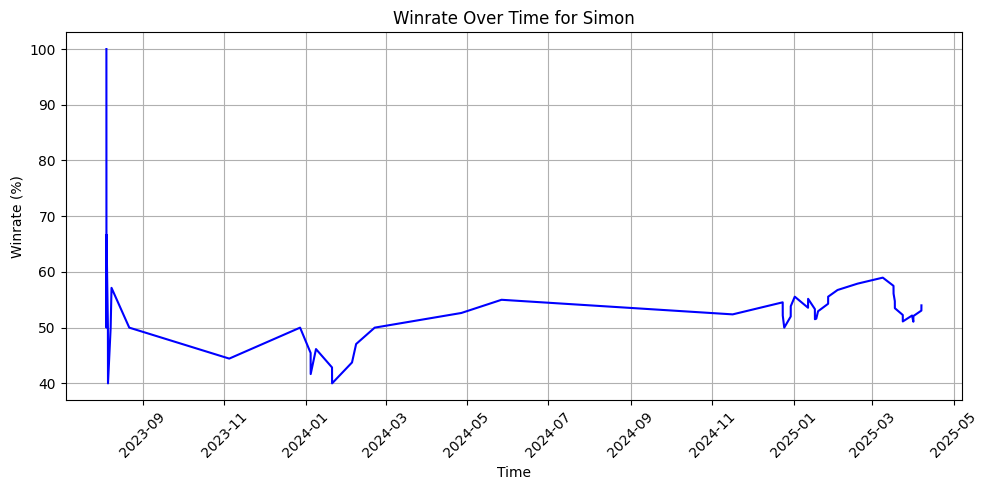

In [ ]:
print(active_players)
for player in active_players:
    plot_winrate(data, player)


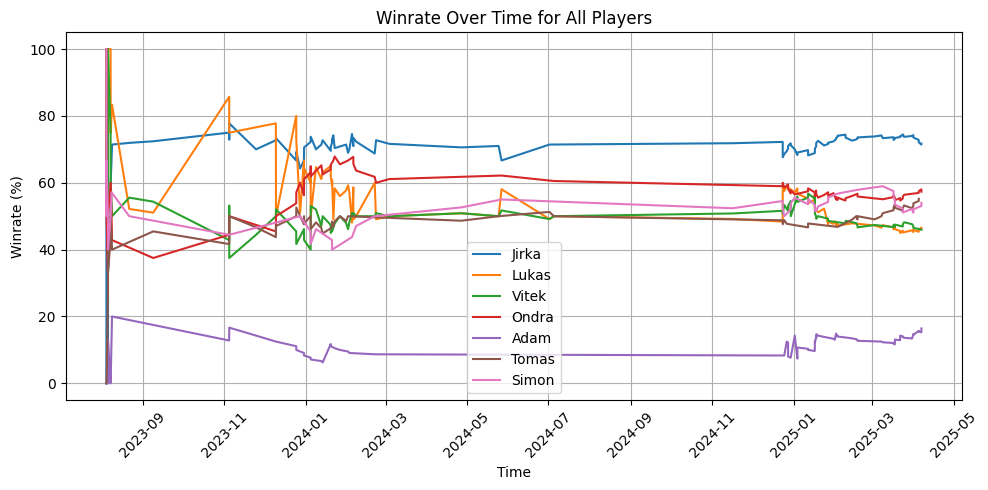

In [ ]:
#show all player winrates in one plot
plot_all_players_winrates(data, active_players)

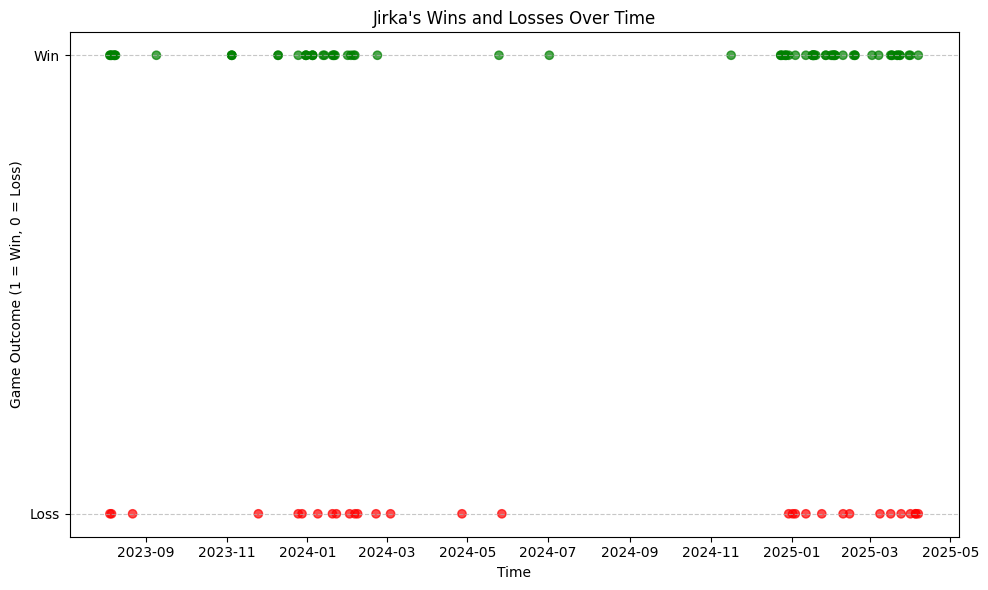

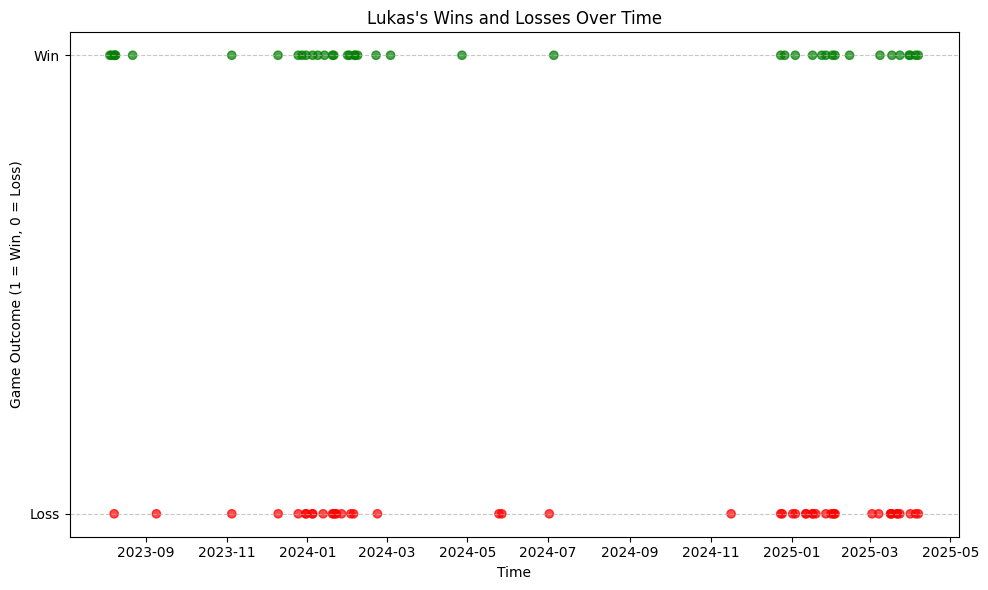

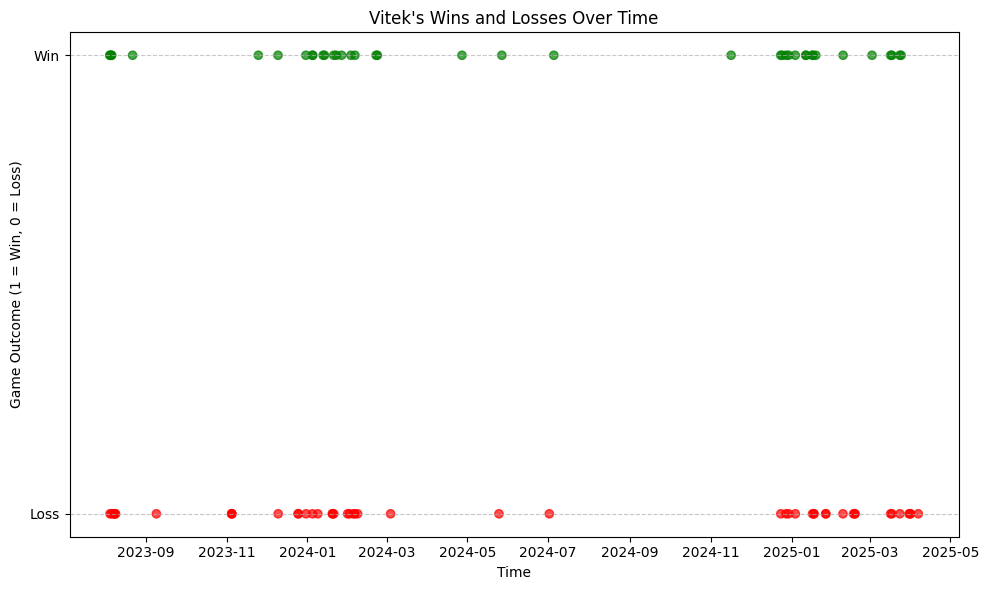

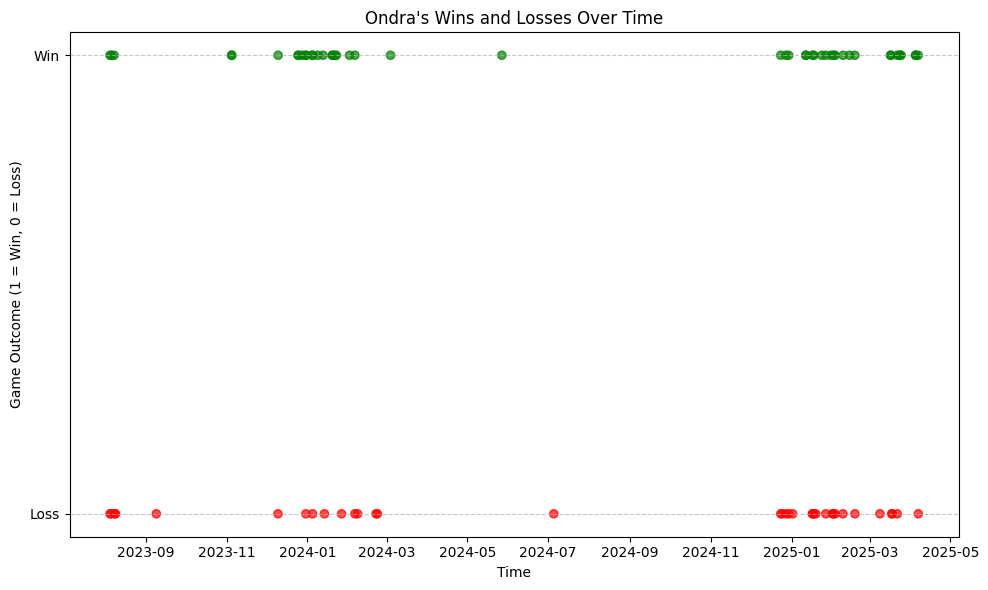

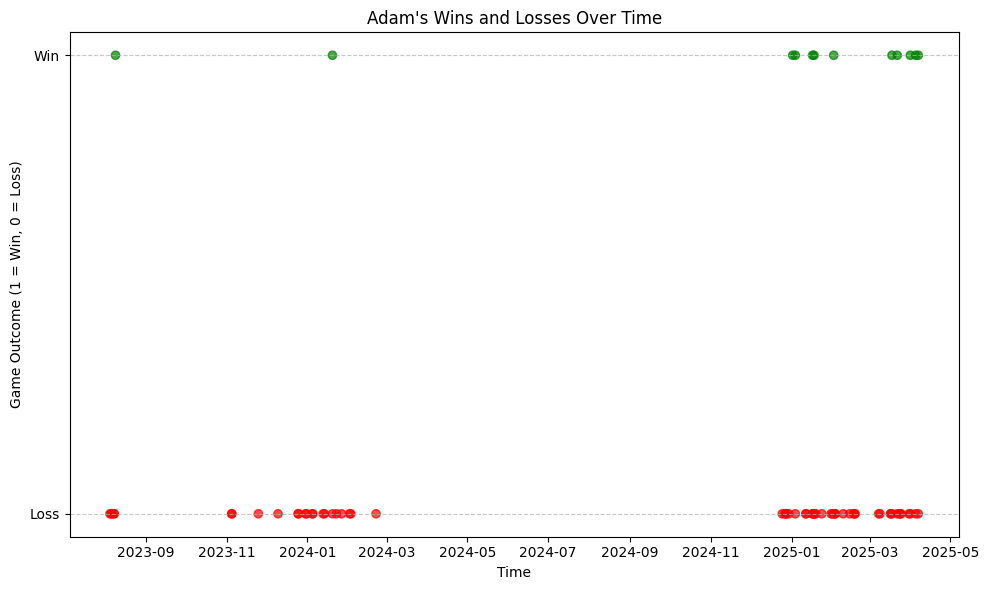

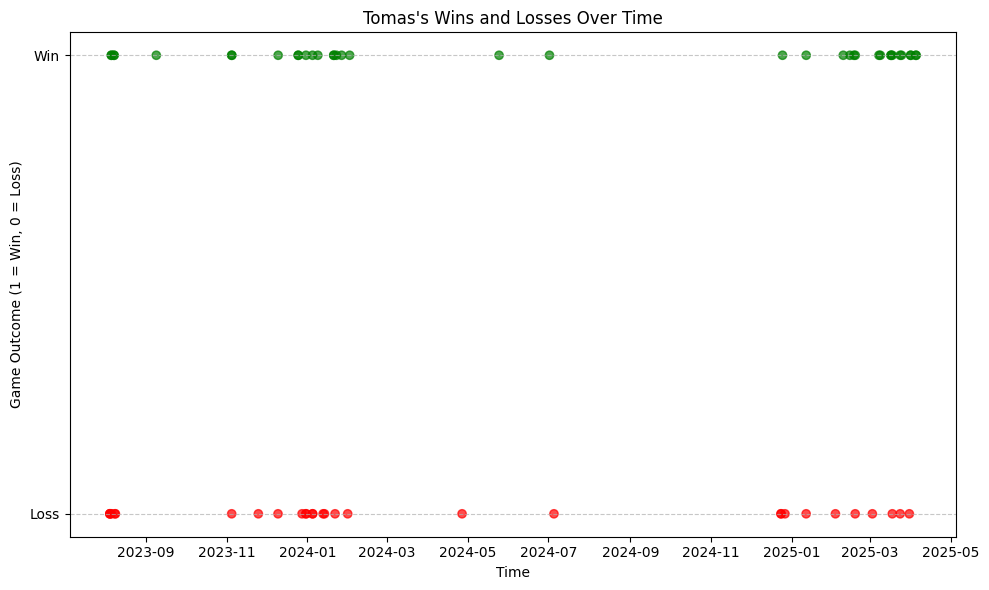

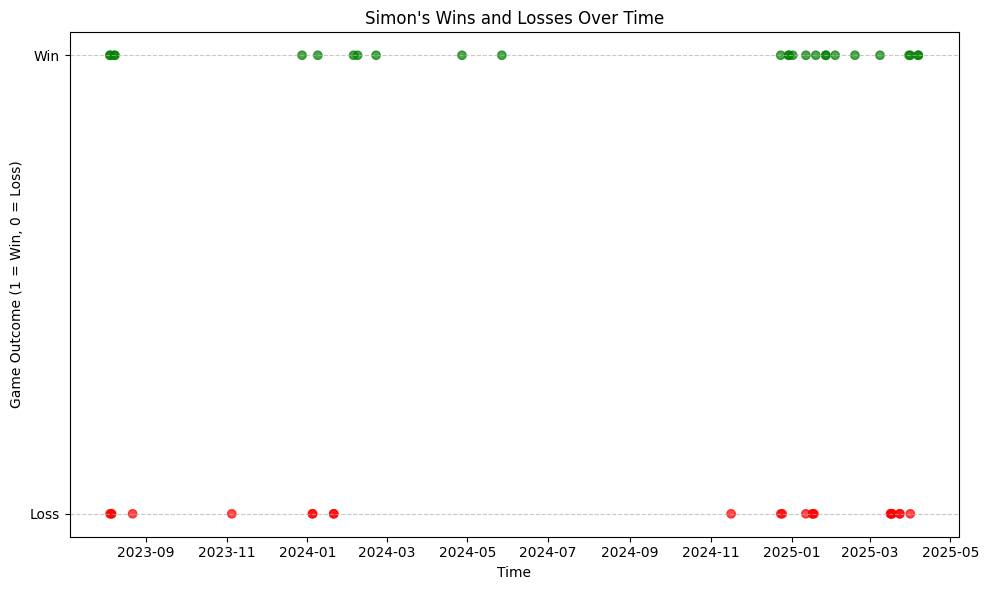

In [ ]:


# Example usage
for player in active_players:
  plot_player_wins_losses(data, player)